<a href="https://colab.research.google.com/github/Adityaraj-2005/LSTM_RNN-comaprison/blob/main/Rnn_Lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
upload=files.upload()


Saving archive (1).zip to archive (1).zip


In [3]:
file_name=list(upload.keys())[0]
df=pd.read_csv(file_name)
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df['sentiment']=df['sentiment'].map({
    'positive':1,
    'negative':0
})

In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [12]:
from sklearn.model_selection import train_test_split
X=df['review'].values
y=df['sentiment'].values
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [13]:
import re

def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    return text

X_train = [clean_text(text) for text in X_train]
X_test = [clean_text(text) for text in X_test]

In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer=Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train_seq=tokenizer.texts_to_sequences(X_train)
X_test_seq=tokenizer.texts_to_sequences(X_test)

In [18]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train_seq=pad_sequences(X_train_seq,maxlen=100,padding='post',truncating='post')
X_test_seq=pad_sequences(X_test_seq,maxlen=100,padding='post',truncating='post')

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Embedding, Dropout, Dense

model_lstm = Sequential([

    Embedding(input_dim=10000, output_dim=64),

    LSTM(64, return_sequences=True),
    Dropout(0.5),

    LSTM(64),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [31]:
model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [33]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

In [34]:
history=model_lstm.fit(
    X_train_seq,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_seq,y_test),
    callbacks=[early_stop]

)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 165ms/step - accuracy: 0.7510 - loss: 0.5094 - val_accuracy: 0.8201 - val_loss: 0.4245
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 164ms/step - accuracy: 0.8533 - loss: 0.3580 - val_accuracy: 0.8213 - val_loss: 0.4101
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 158ms/step - accuracy: 0.8823 - loss: 0.3021 - val_accuracy: 0.8323 - val_loss: 0.4206
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 143s 160ms/step - accuracy: 0.8946 - loss: 0.2795 - val_accuracy: 0.8395 - val_loss: 0.4378
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 164ms/step - accuracy: 0.9189 - loss: 0.2240 - val_accuracy: 0.8423 - val_loss: 0.4070
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - accuracy: 0.9304 - loss: 0.1968 - val_accuracy: 0.8401 - val_loss: 0.4499
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 164ms/step - accuracy: 0.9451 - loss: 0.1600 - val_accuracy: 0.8325 - val_loss: 0.5272
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - accuracy: 0.9583 - l

In [35]:
loss,accuracy=model_lstm.evaluate(X_test_seq,y_test)
print(f'Loss: {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.8423 - loss: 0.4070
Loss: 0.41
Accuracy: 84.23%


NOW Bidirectional GRU


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Bidirectional, Dropout, Dense
model_bigru = Sequential([

    Embedding(input_dim=10000, output_dim=64),

    Bidirectional(GRU(64, return_sequences=True)),
    Dropout(0.5),

    Bidirectional(GRU(64)),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])
model_bigru.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_gru = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

In [38]:
history_bigru = model_bigru.fit(
    X_train_seq,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_seq, y_test),
    callbacks=[early_stop_gru]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 257s 399ms/step - accuracy: 0.7724 - loss: 0.4552 - val_accuracy: 0.8419 - val_loss: 0.3611
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 261s 397ms/step - accuracy: 0.8718 - loss: 0.3100 - val_accuracy: 0.8411 - val_loss: 0.3652
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 265s 401ms/step - accuracy: 0.9063 - loss: 0.2398 - val_accuracy: 0.8434 - val_loss: 0.4066
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 256s 410ms/step - accuracy: 0.9382 - loss: 0.1653 - val_accuracy: 0.8380 - val_loss: 0.4835
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 258s 404ms/step - accuracy: 0.9634 - loss: 0.1047 - val_accuracy: 0.8309 - val_loss: 0.5766
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 264s 408ms/step - accuracy: 0.9760 - loss: 0.0682 - val_accuracy: 0.8265 - val_loss: 0.7473
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


In [41]:
loss_bigru, accuracy_bigru = model_bigru.evaluate(
    X_test_seq,
    y_test
)

print("BiGRU Loss:", loss_bigru)
print("BiGRU Accuracy:", accuracy_bigru)

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.8434 - loss: 0.4066
BiGRU Loss: 0.40656960010528564
BiGRU Accuracy: 0.8434000015258789


In [42]:
print("\n----- MODEL COMPARISON -----")

print("LSTM Accuracy:", accuracy)
print("LSTM Loss:", loss)

print("\nBiGRU Accuracy:", accuracy_bigru)
print("BiGRU Loss:", loss_bigru)

if accuracy_bigru > accuracy:
    print("\nBiGRU performs better ✅")
else:
    print("\nLSTM performs better ✅")


----- MODEL COMPARISON -----
LSTM Accuracy: 0.8434000015258789
LSTM Loss: 0.40656960010528564

BiGRU Accuracy: 0.8434000015258789
BiGRU Loss: 0.40656960010528564

LSTM performs better ✅


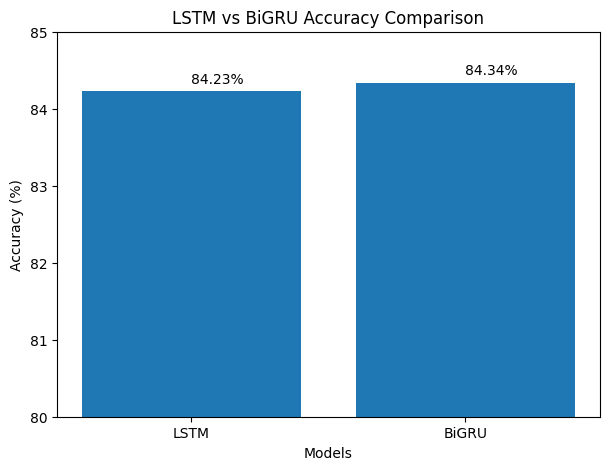

In [43]:
import matplotlib.pyplot as plt

models = ['LSTM', 'BiGRU']
accuracies = [84.23, 84.34]

plt.figure(figsize=(7, 5))
plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("LSTM vs BiGRU Accuracy Comparison")

plt.ylim(80, 85)

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.1, f'{value}%')

plt.show()

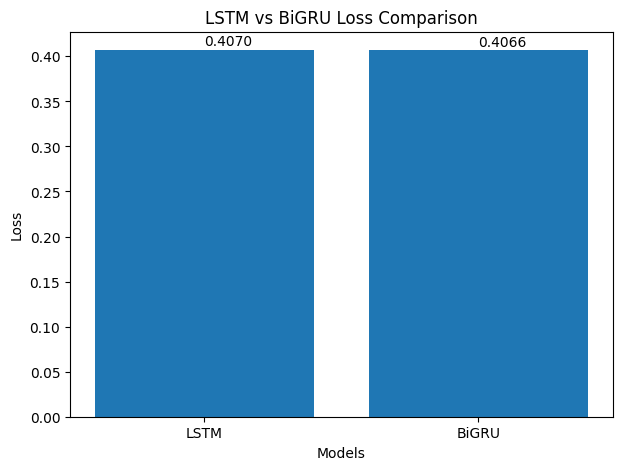

In [44]:
models = ['LSTM', 'BiGRU']
losses = [0.4070, 0.4066]

plt.figure(figsize=(7, 5))
plt.bar(models, losses)

plt.xlabel("Models")
plt.ylabel("Loss")
plt.title("LSTM vs BiGRU Loss Comparison")

for i, value in enumerate(losses):
    plt.text(i, value + 0.005, f'{value:.4f}')

plt.show()

In [46]:
review = "This movie was absolutely amazing and I loved it"

seq = pad_sequences(
    tokenizer.texts_to_sequences([clean_text(review)]),
    maxlen=100,
    padding='post'
)

lstm_prob = model_lstm.predict(seq, verbose=0)[0][0]
bigru_prob = model_bigru.predict(seq, verbose=0)[0][0]

print("LSTM:", int(lstm_prob >= 0.5), "Accuracy:", round(lstm_prob * 100, 2), "%")
print("BiGRU:", int(bigru_prob >= 0.5), "Accuracy:", round(bigru_prob * 100, 2), "%")

LSTM: 1 Accuracy: 96.83 %
BiGRU: 1 Accuracy: 98.4 %
